<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_08/avcad_ex08_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 8**

Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

### AI Use Declaration and Prompts Used

I acknowledge that I used **Gemini Pro** as an AI tool provided under my university access to assist in the preparation of this work. All AI-generated suggestions were carefully reviewed, edited, and verified by me to ensure accuracy, originality, and compliance with university academic integrity policies. The prompts used during this process included:

- `What's the difference between single, complete, average and ward linkage in agglomerative clustering?`
- `How do I plot a heatmap with row/column dendrograms in Python (seaborn clustermap)?`
- `How can a variable dendrogram help to pick non-redundant predictors for regression?`

I take full responsibility for the final submitted work and confirm that the use of AI aligns with the guidelines established by the university. I am also willing to provide the full AI conversation transcript upon request for transparency and verification purposes.

### Exercise Questions

Using the dataset in `EFIplus_medit.zip`:

1. Run agglomerative cluster analysis using different linkage methods based on quantitative environmental variables (see previous exercise), using sites from the Douro and Tejo basins.
2. Plot a heatmap and a dendrogram by clustering the rows (sites) using average linkage.
3. Plot a dendrogram that clusters the environmental variables instead (columns) using average linkage – discuss how this would help to select variables for e.g. a regression-based analysis.

(NOTE: to transpose a dataframe use `<dataframe>.T`)

## 1. Setup and Data Preparation

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

In [5]:
# Load data from GitHub
url = 'https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip'
df = pd.read_csv(url, compression='zip', sep=';')

# Clean dataset (same as previous exercises)
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))
df2 = df.dropna().copy()

print(f"Full dataset: {df2.shape}")

Full dataset: (2822, 154)


In [6]:
# @title Global Plot Settings

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

### Subset: Douro and Tejo basins, with the transformed environmental variables from Exercise 6

We apply the same `log1p` transformation to the right-skewed variables (Altitude, Actual_river_slope, prec_ann_catch) that we identified in Exercise 6, then keep only the rows from the Douro and Tejo catchments.

In [7]:
# log1p transform the skewed variables
for var in ['Altitude', 'Actual_river_slope', 'prec_ann_catch']:
    df2[f'{var}_log'] = np.log1p(df2[var])

env_vars = ['Altitude_log', 'Actual_river_slope_log', 'Elevation_mean_catch',
            'prec_ann_catch_log', 'temp_ann', 'temp_jan', 'temp_jul']

# Keep only Douro and Tejo sites
df_dt = df2[df2['Catchment_name'].isin(['Douro', 'Tejo'])].copy()
print(f"Douro + Tejo sites: {df_dt.shape}")
print(df_dt['Catchment_name'].value_counts())

# Build the analysis matrix
X = df_dt[env_vars].copy()
X.head()

Douro + Tejo sites: (507, 157)
Catchment_name
Douro    272
Tejo     235
Name: count, dtype: int64


,Altitude_log,Actual_river_slope_log,Elevation_mean_catch,prec_ann_catch_log,temp_ann,temp_jan,temp_jul
18,7.073270,0.001000,1687.103217,6.698382,9.3,1.4,18.4
19,6.946014,1.181114,1293.238318,6.478557,10.4,2.2,19.6
28,6.456770,0.233490,967.398405,6.244068,12.6,3.8,21.3
32,6.792344,1.363282,1088.329483,6.318528,11.2,2.7,20.5
43,6.771936,1.510722,985.273741,6.253565,11.1,2.6,20.0


In [8]:
# Standardize because the variables are in different units/scales
scaler = StandardScaler()
Xs = pd.DataFrame(scaler.fit_transform(X), columns=env_vars, index=X.index)
Xs.describe().round(3)

,Altitude_log,Actual_river_slope_log,Elevation_mean_catch,prec_ann_catch_log,temp_ann,temp_jan,temp_jul
count,507.000,507.000,507.000,507.000,507.000,507.000,507.000
mean,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-3.992,-1.824,-1.930,-2.638,-2.756,-2.389,-2.968
25%,-0.606,-0.799,-0.877,-0.772,-0.749,-0.803,-0.711
50%,0.275,0.051,0.087,0.124,0.119,-0.051,-0.021
75%,0.749,0.609,0.545,0.772,0.879,0.784,0.794
max,1.503,3.069,3.274,2.276,1.530,1.828,2.361


---
## 2. Q1: Agglomerative clustering with different linkage methods

Agglomerative clustering is a bottom-up hierarchical clustering algorithm. It starts by treating each data point as its own cluster, then iteratively merges the closest pairs of clusters according to a chosen distance metric and linkage criterion, continuing until all data points are grouped into a single cluster.



![Image](https://media.geeksforgeeks.org/wp-content/uploads/20251117144305409428/agglomerative_clustering.webp)

 The **linkage method** defines what "closest" means between clusters:

- **single** — distance between the two closest points (tends to produce long, chain-like clusters)
- **complete** — distance between the two farthest points (tight, compact clusters)
- **average** — mean of all pairwise distances (compromise between single & complete)
- **ward** — minimizes the increase in total within-cluster variance (compact, similarly-sized clusters)

All linkages are computed on Euclidean distances between standardized environmental profiles.

![image2](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQikWkn_lxCJVX9D-RYs3JnKYnaJj5k8BVrRQ&s)

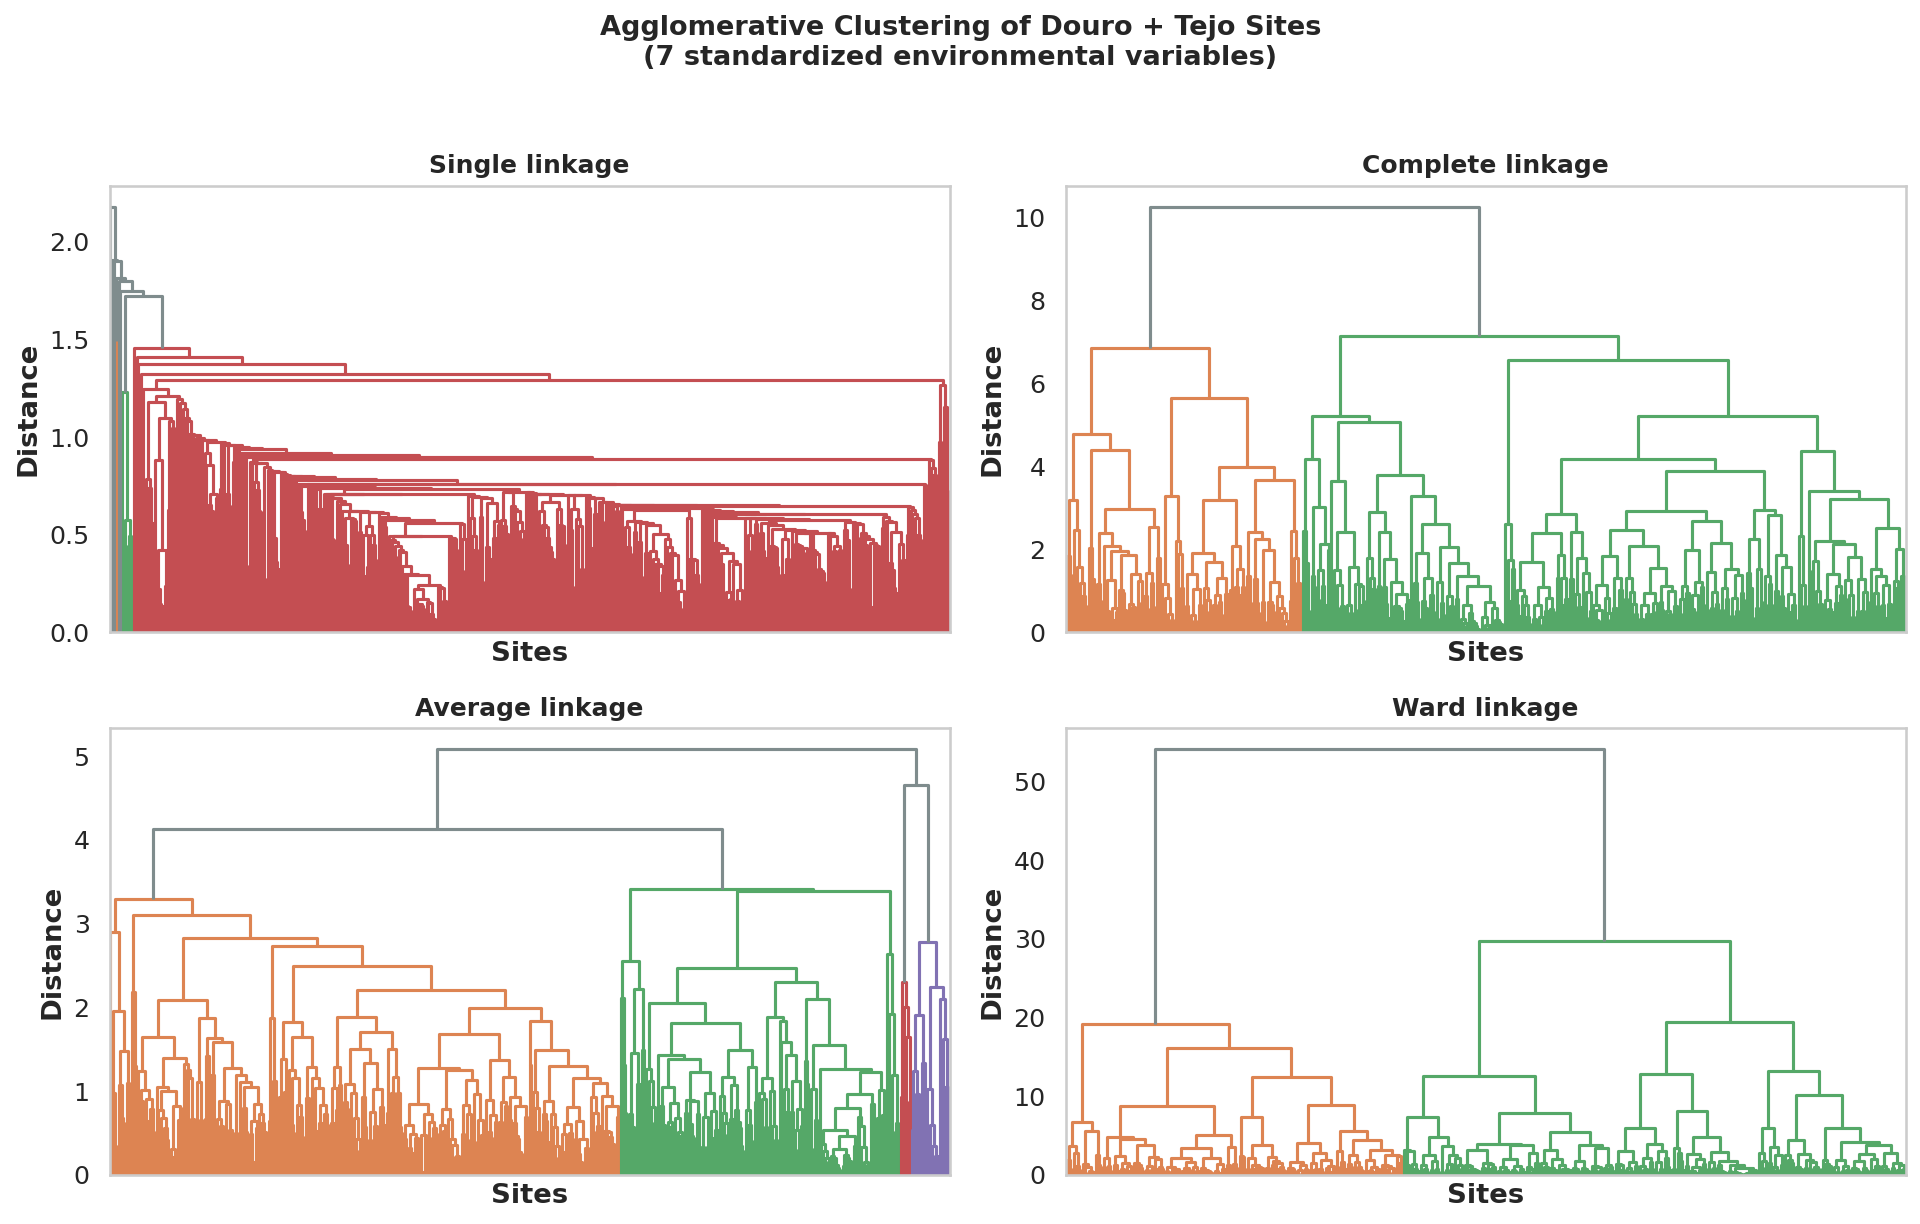

In [9]:
# @title Fit four linkage methods and compare dendrograms

methods = ['single', 'complete', 'average', 'ward']
linkages = {m: linkage(Xs.values, method=m, metric='euclidean') for m in methods}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, m in enumerate(methods):
    dendrogram(linkages[m], ax=axes[i], color_threshold=None,
               no_labels=True, above_threshold_color='#7f8c8d')
    axes[i].set_title(f"{m.capitalize()} linkage", fontsize=12)
    axes[i].set_xlabel("Sites")
    axes[i].set_ylabel("Distance")
    axes[i].grid(False)

fig.suptitle("Agglomerative Clustering of Douro + Tejo Sites\n(7 standardized environmental variables)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The four linkages produce very different tree shapes:
- **Single** linkage produces the characteristic *chaining* effect, with long stems and one site grafting on at a time.
- **Complete** linkage gives more balanced, compact clusters.
- **Average** linkage is a clean compromise and is typically the most informative.
- **Ward** linkage produces well-separated, similarly-sized clusters and is the natural choice when the goal is to define group structure for downstream analysis.

---
## 3. Q2: Heatmap with row (site) dendrogram — average linkage

A **clustermap** plots the standardized data matrix with sites reordered according to the hierarchical clustering. Sites with similar environmental profiles end up next to each other, and the row dendrogram shows the merging structure.

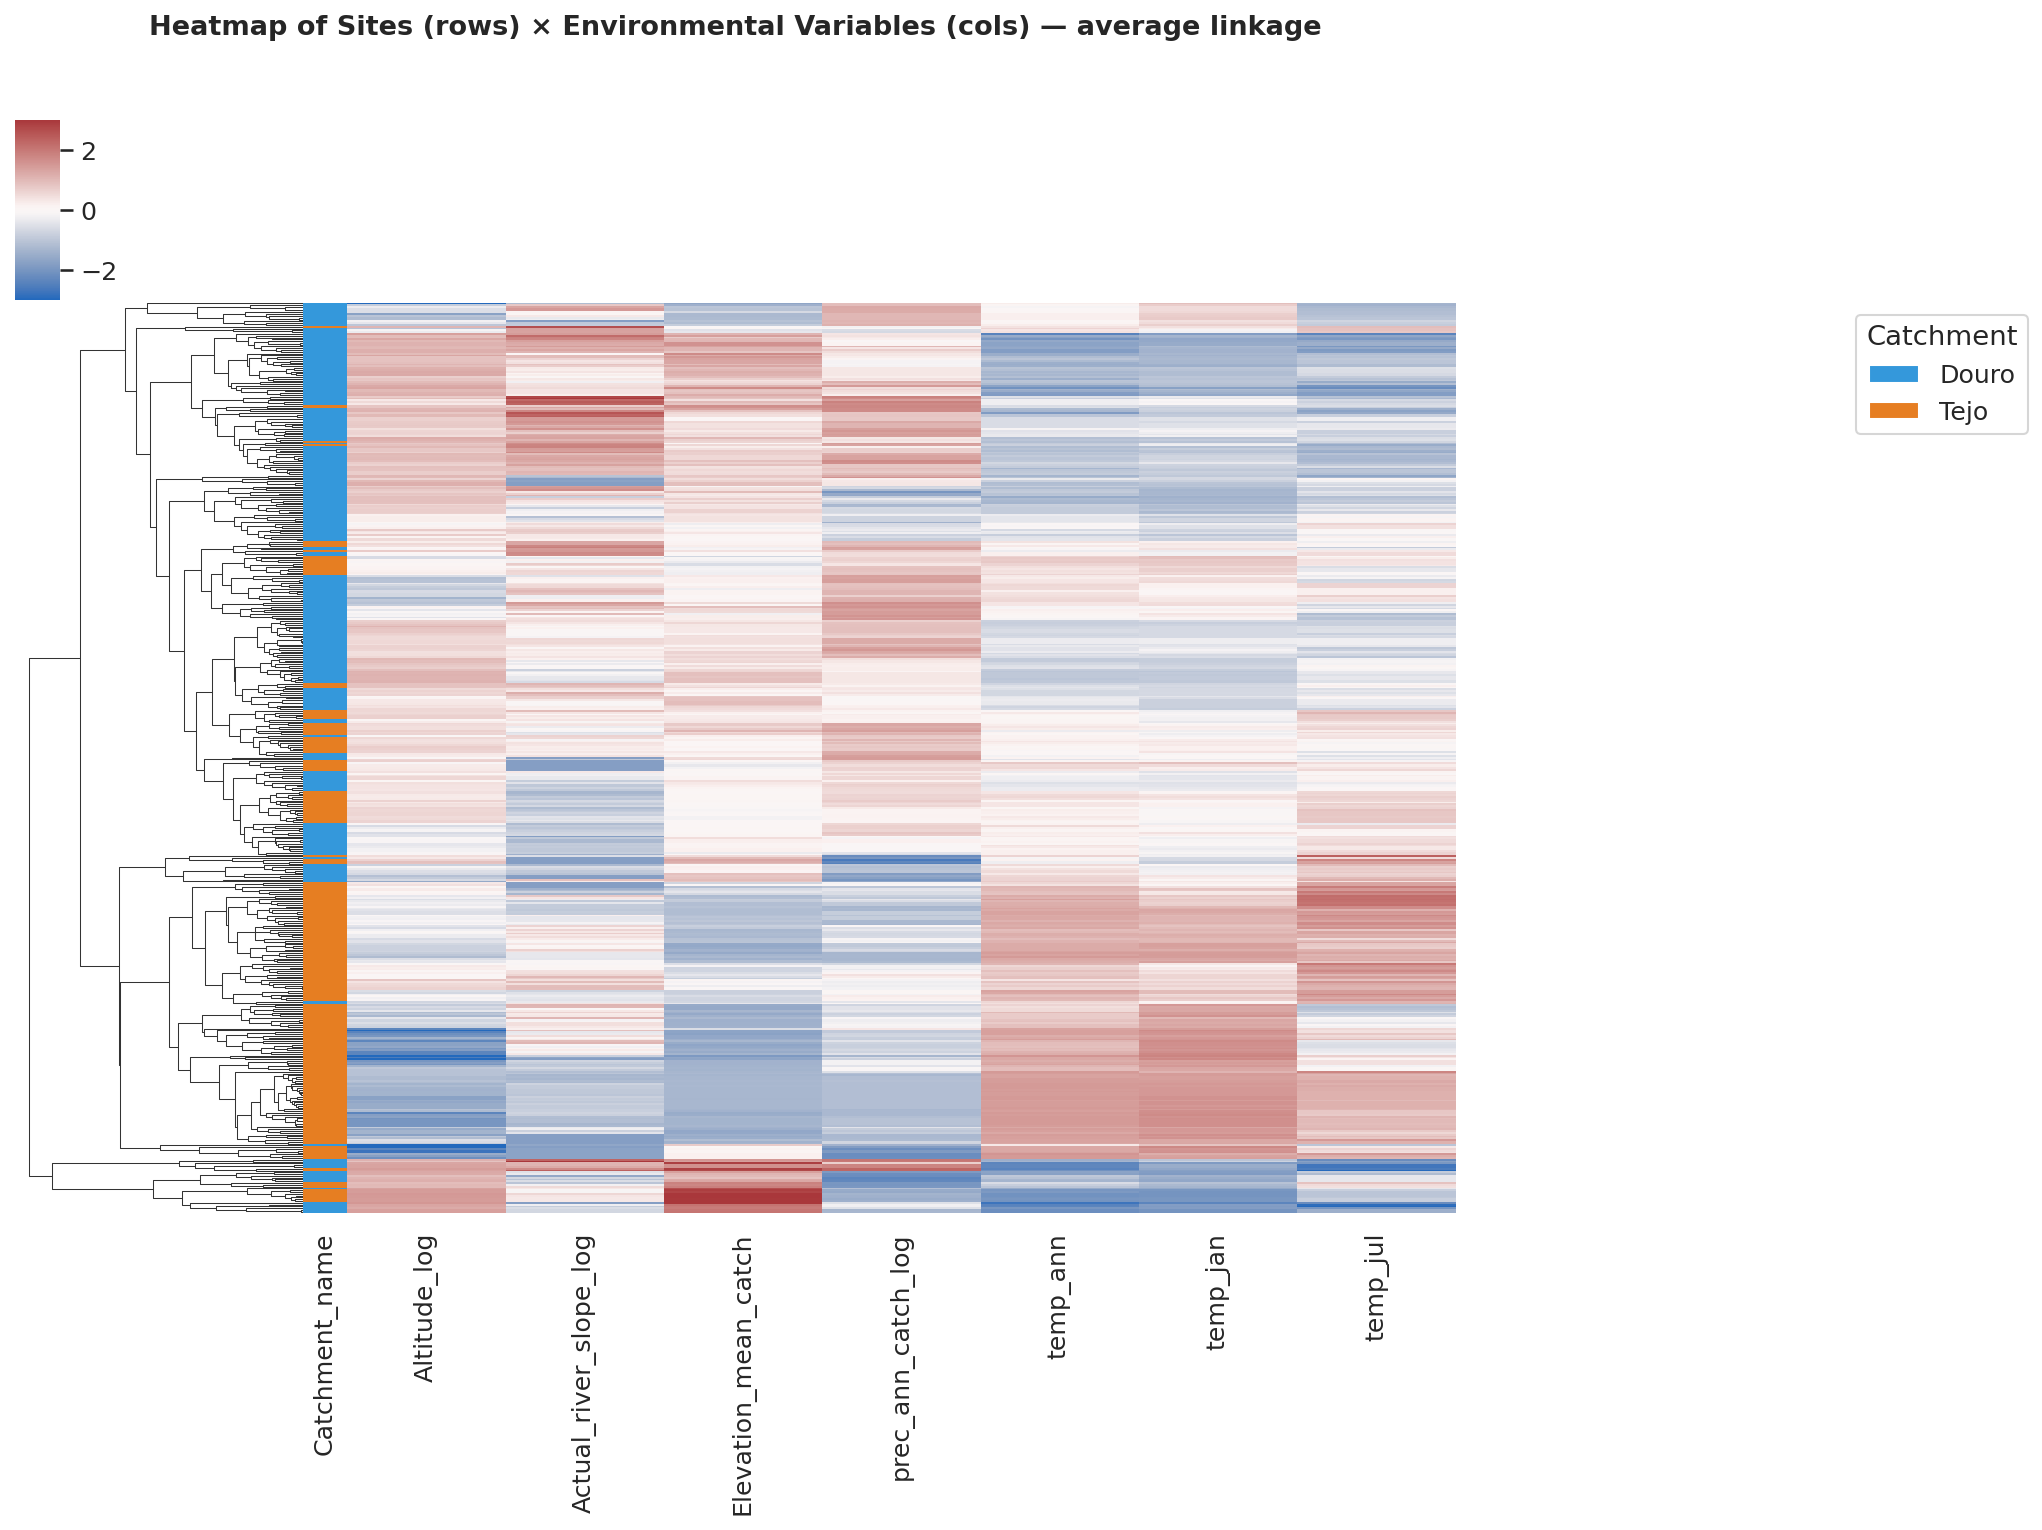

In [10]:
# Color-code the row labels by catchment so we can see if Douro and Tejo sites separate
row_colors = df_dt['Catchment_name'].map({'Douro': '#3498db', 'Tejo': '#e67e22'})

g = sns.clustermap(
    Xs,
    method='average', metric='euclidean',
    row_cluster=True, col_cluster=False,
    cmap='vlag', center=0, vmin=-3, vmax=3,
    figsize=(10, 10),
    yticklabels=False,
    row_colors=row_colors,
    cbar_pos=(0.02, 0.83, 0.03, 0.12),
)
g.fig.suptitle("Heatmap of Sites (rows) × Environmental Variables (cols) — average linkage",
               fontsize=13, fontweight='bold', y=1.02)

# Manual legend for the row-color bar
from matplotlib.patches import Patch
g.ax_heatmap.legend(
    handles=[Patch(facecolor='#3498db', label='Douro'),
             Patch(facecolor='#e67e22', label='Tejo')],
    title='Catchment', bbox_to_anchor=(1.35, 1.0), loc='upper left',
)
plt.show()

---
## 4. Q3: Dendrogram of the *Variables* via Average Linkage

By transposing the matrix (`Xs.T`) we cluster the **environmental variables** instead of the sites. Two variables that vary together across sites end up close in the tree; two variables that capture independent gradients sit on different branches.

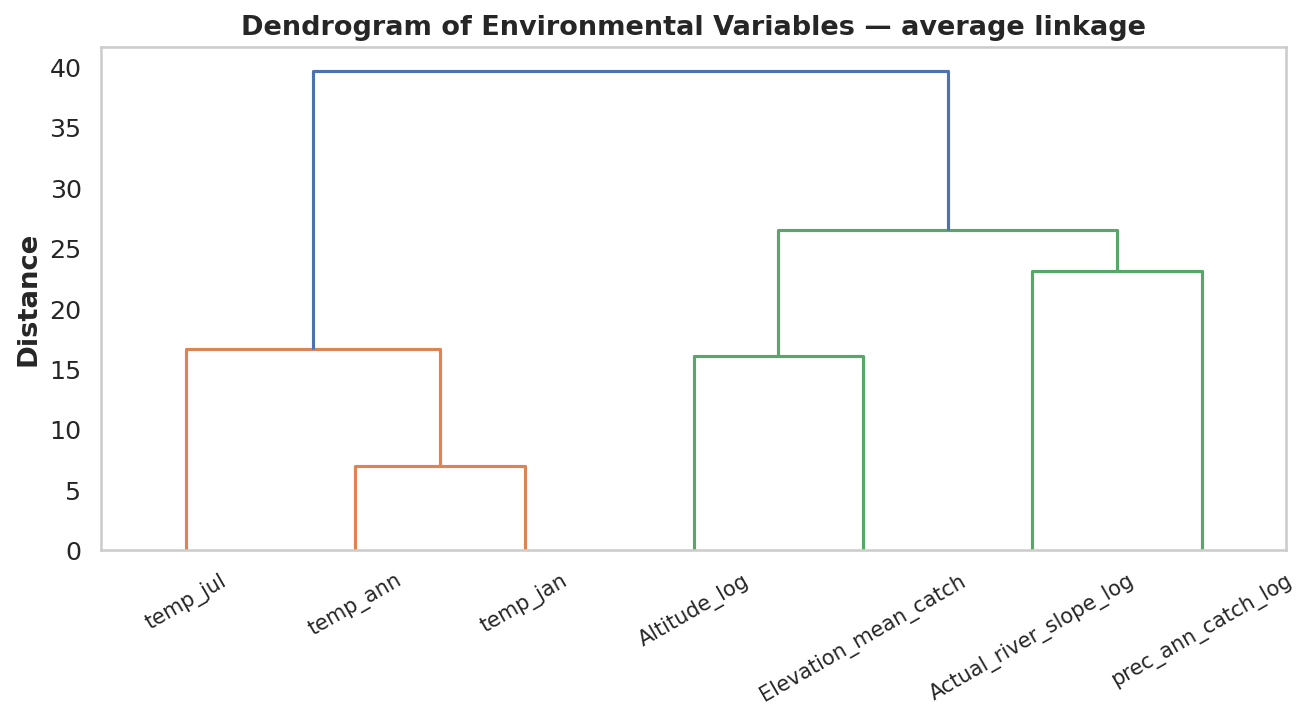

In [11]:
Z_vars = linkage(Xs.T.values, method='average', metric='euclidean')

fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(Z_vars, labels=env_vars, leaf_rotation=30, leaf_font_size=10,
           color_threshold=0.7*max(Z_vars[:, 2]), ax=ax)
ax.set_title("Dendrogram of Environmental Variables — average linkage",
             fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Distance")
ax.grid(False)
plt.tight_layout()
plt.show()

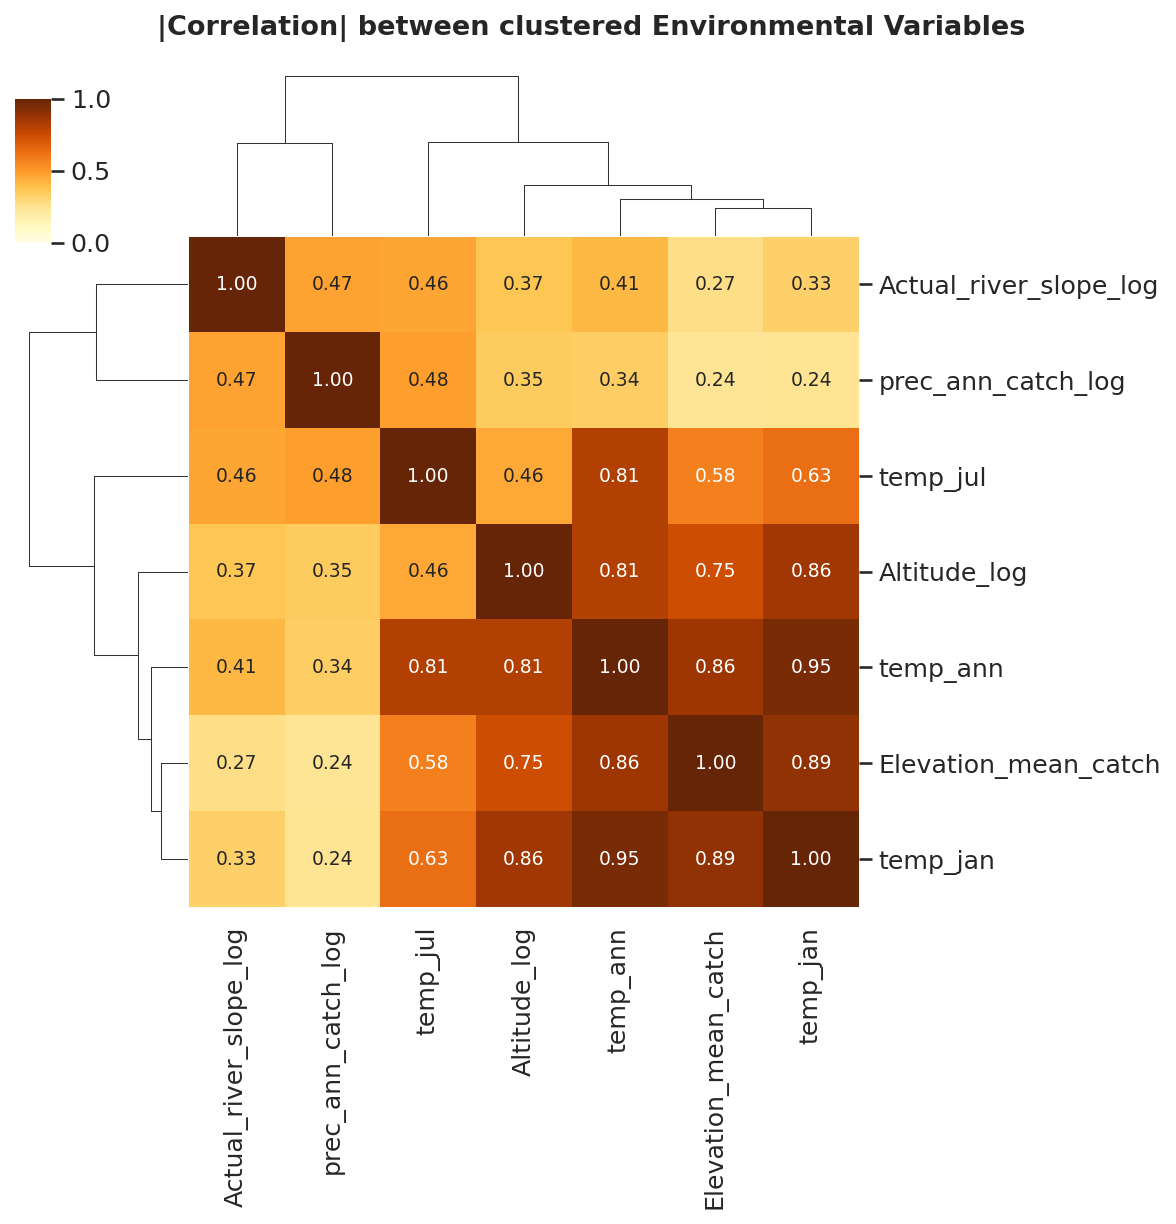

In [12]:
# @title Combined view — heatmap of |correlation| between variables, with variable dendrogram

g = sns.clustermap(
    Xs.corr().abs(),
    method='average', metric='euclidean',
    cmap='YlOrBr', vmin=0, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    figsize=(8, 8),
    cbar_pos=(0.02, 0.83, 0.03, 0.12),
)
g.fig.suptitle("|Correlation| between clustered Environmental Variables",
               fontsize=13, fontweight='bold', y=1.02)
plt.show()

The variable dendrogram shows that the seven environmental predictors group into a few small, tight clusters:

- A temperature group with `temp_ann`, `temp_jan`, and `temp_jul` — these three join together at a very low distance, meaning they give almost the same information.
- A height group with `Altitude_log` and `Elevation_mean_catch`, which also cluster closely because higher sites are found in higher catchments.
- `Actual_river_slope_log` and `prec_ann_catch_log` are more separate and sit on their own branches.

---
## 5. Q1–Q3 Redone with the Reduced Variable Set

Following the recommendation from Q3, we drop the redundant predictors and keep **one representative per tight cluster**:

- From the temperature group, keep `temp_ann` and drop `temp_jan` and `temp_jul`.
- From the elevation group, keep `Elevation_mean_catch` and drop `Altitude_log`.
- Keep `Actual_river_slope_log` and `prec_ann_catch_log` because they sit on independent branches.

In [13]:
# @title Define the reduced (non-redundant) variable set and standardize

# Per the Q3 recommendation:
#   - keep ONE temperature variable: temp_ann (drop temp_jan, temp_jul)
#   - keep ONE elevation variable:   Elevation_mean_catch (drop Altitude_log)
#   - keep the two independent predictors as-is: Actual_river_slope_log, prec_ann_catch_log
env_vars_red = ['Elevation_mean_catch', 'Actual_river_slope_log',
                'prec_ann_catch_log', 'temp_ann']

X_red  = df_dt[env_vars_red].copy()
Xs_red = pd.DataFrame(StandardScaler().fit_transform(X_red),
                      columns=env_vars_red, index=X_red.index)

Xs_red.describe().round(3)

,Elevation_mean_catch,Actual_river_slope_log,prec_ann_catch_log,temp_ann
count,507.000,507.000,507.000,507.000
mean,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001
min,-1.930,-1.824,-2.638,-2.756
25%,-0.877,-0.799,-0.772,-0.749
50%,0.087,0.051,0.124,0.119
75%,0.545,0.609,0.772,0.879
max,3.274,3.069,2.276,1.530


### Q1 Redone

We rerun the four linkage methods using the 4 standardized non-redundant variables. The expectation is that the chaining/balance behavior of each linkage stays similar to the 7-variable case (the dominant temperature/elevation gradient is still there), but the merges are driven by genuinely independent dimensions.

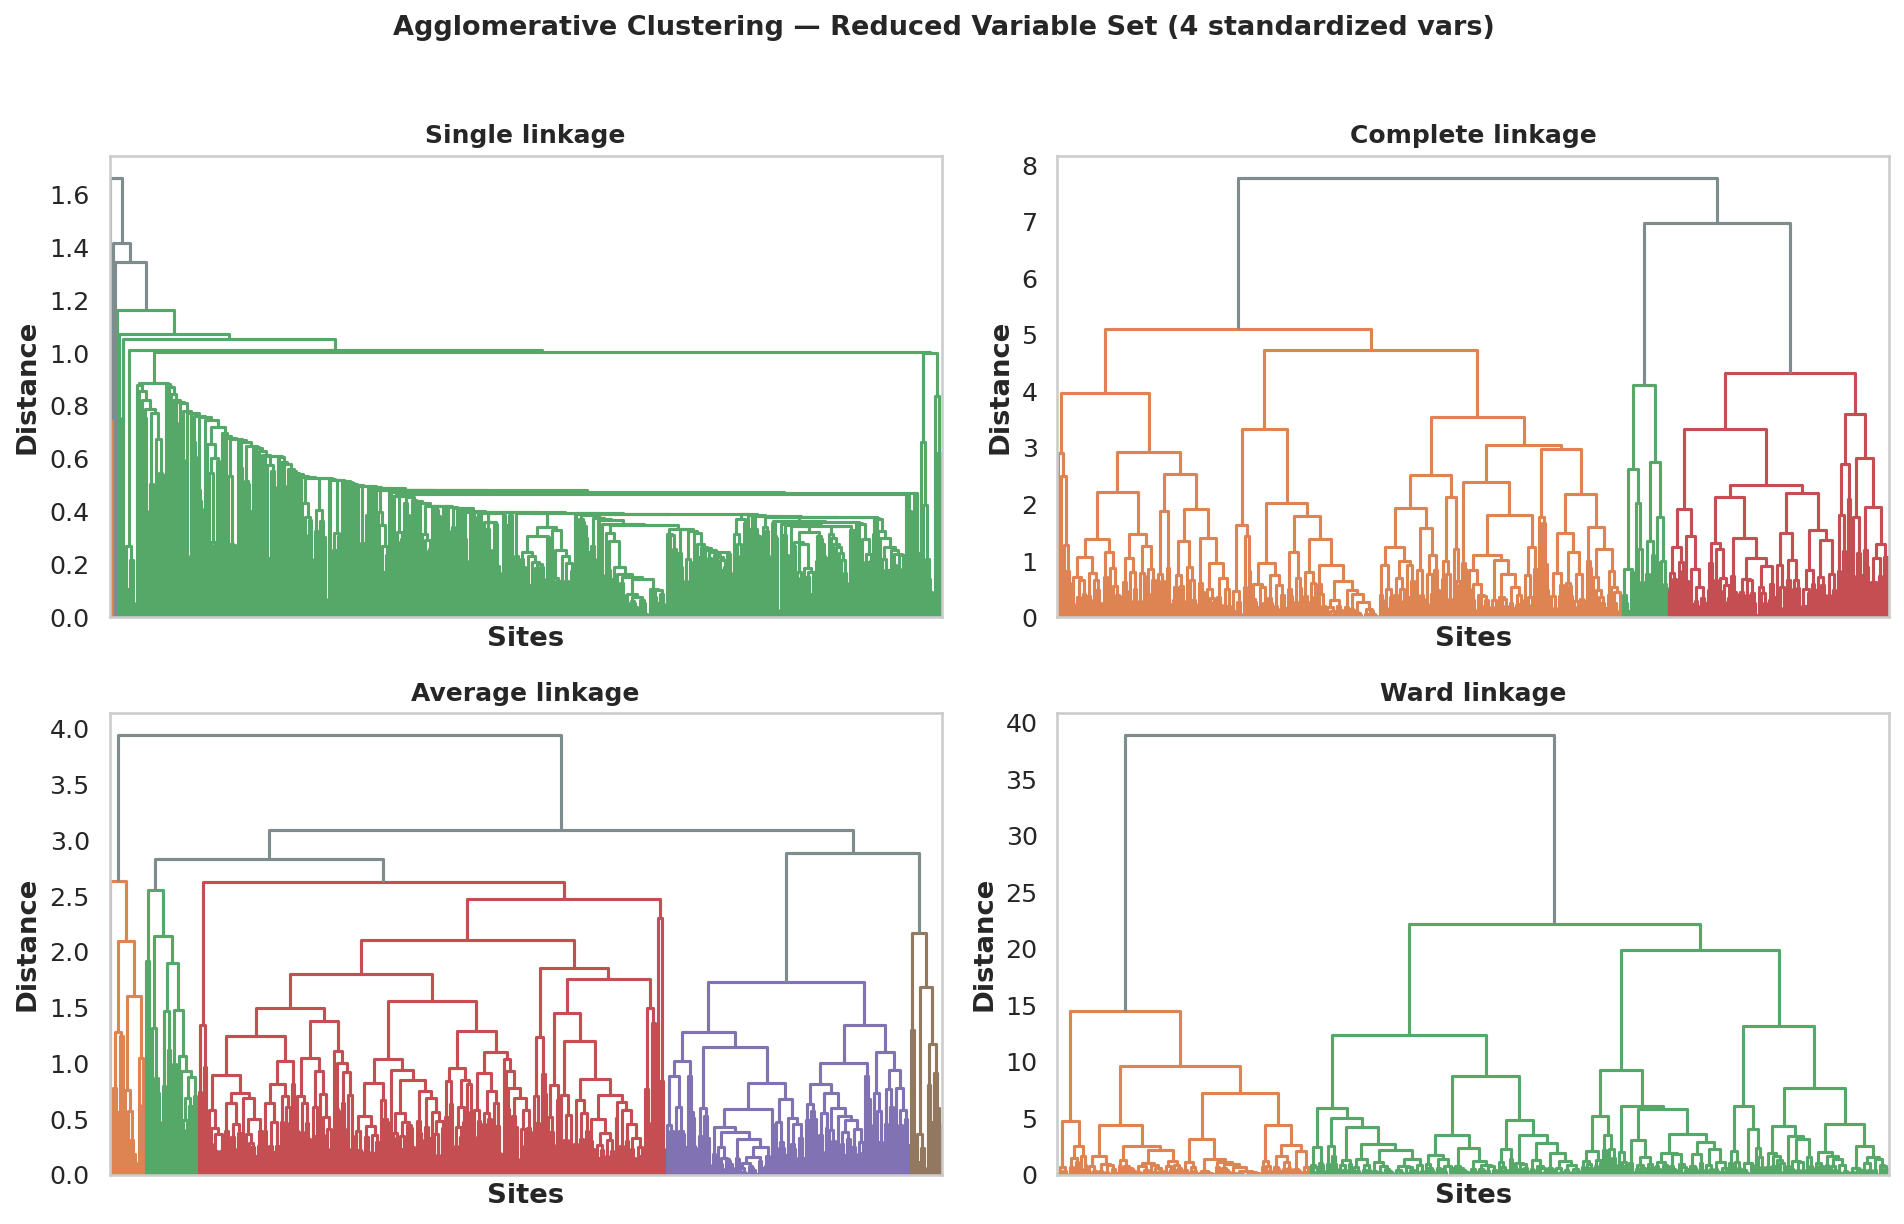

In [14]:
# @title Fit the Four Linkage Methods on the Reduced Data

linkages_red = {m: linkage(Xs_red.values, method=m, metric='euclidean')
                for m in methods}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, m in enumerate(methods):
    dendrogram(linkages_red[m], ax=axes[i], color_threshold=None,
               no_labels=True, above_threshold_color='#7f8c8d')
    axes[i].set_title(f"{m.capitalize()} linkage", fontsize=12)
    axes[i].set_xlabel("Sites")
    axes[i].set_ylabel("Distance")
    axes[i].grid(False)

fig.suptitle("Agglomerative Clustering — Reduced Variable Set (4 standardized vars)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Q2 Redone

With only four columns now, the heatmap should still show a clear warm-lowland vs cold-upland separation, but without the visual redundancy of the three temperature columns.

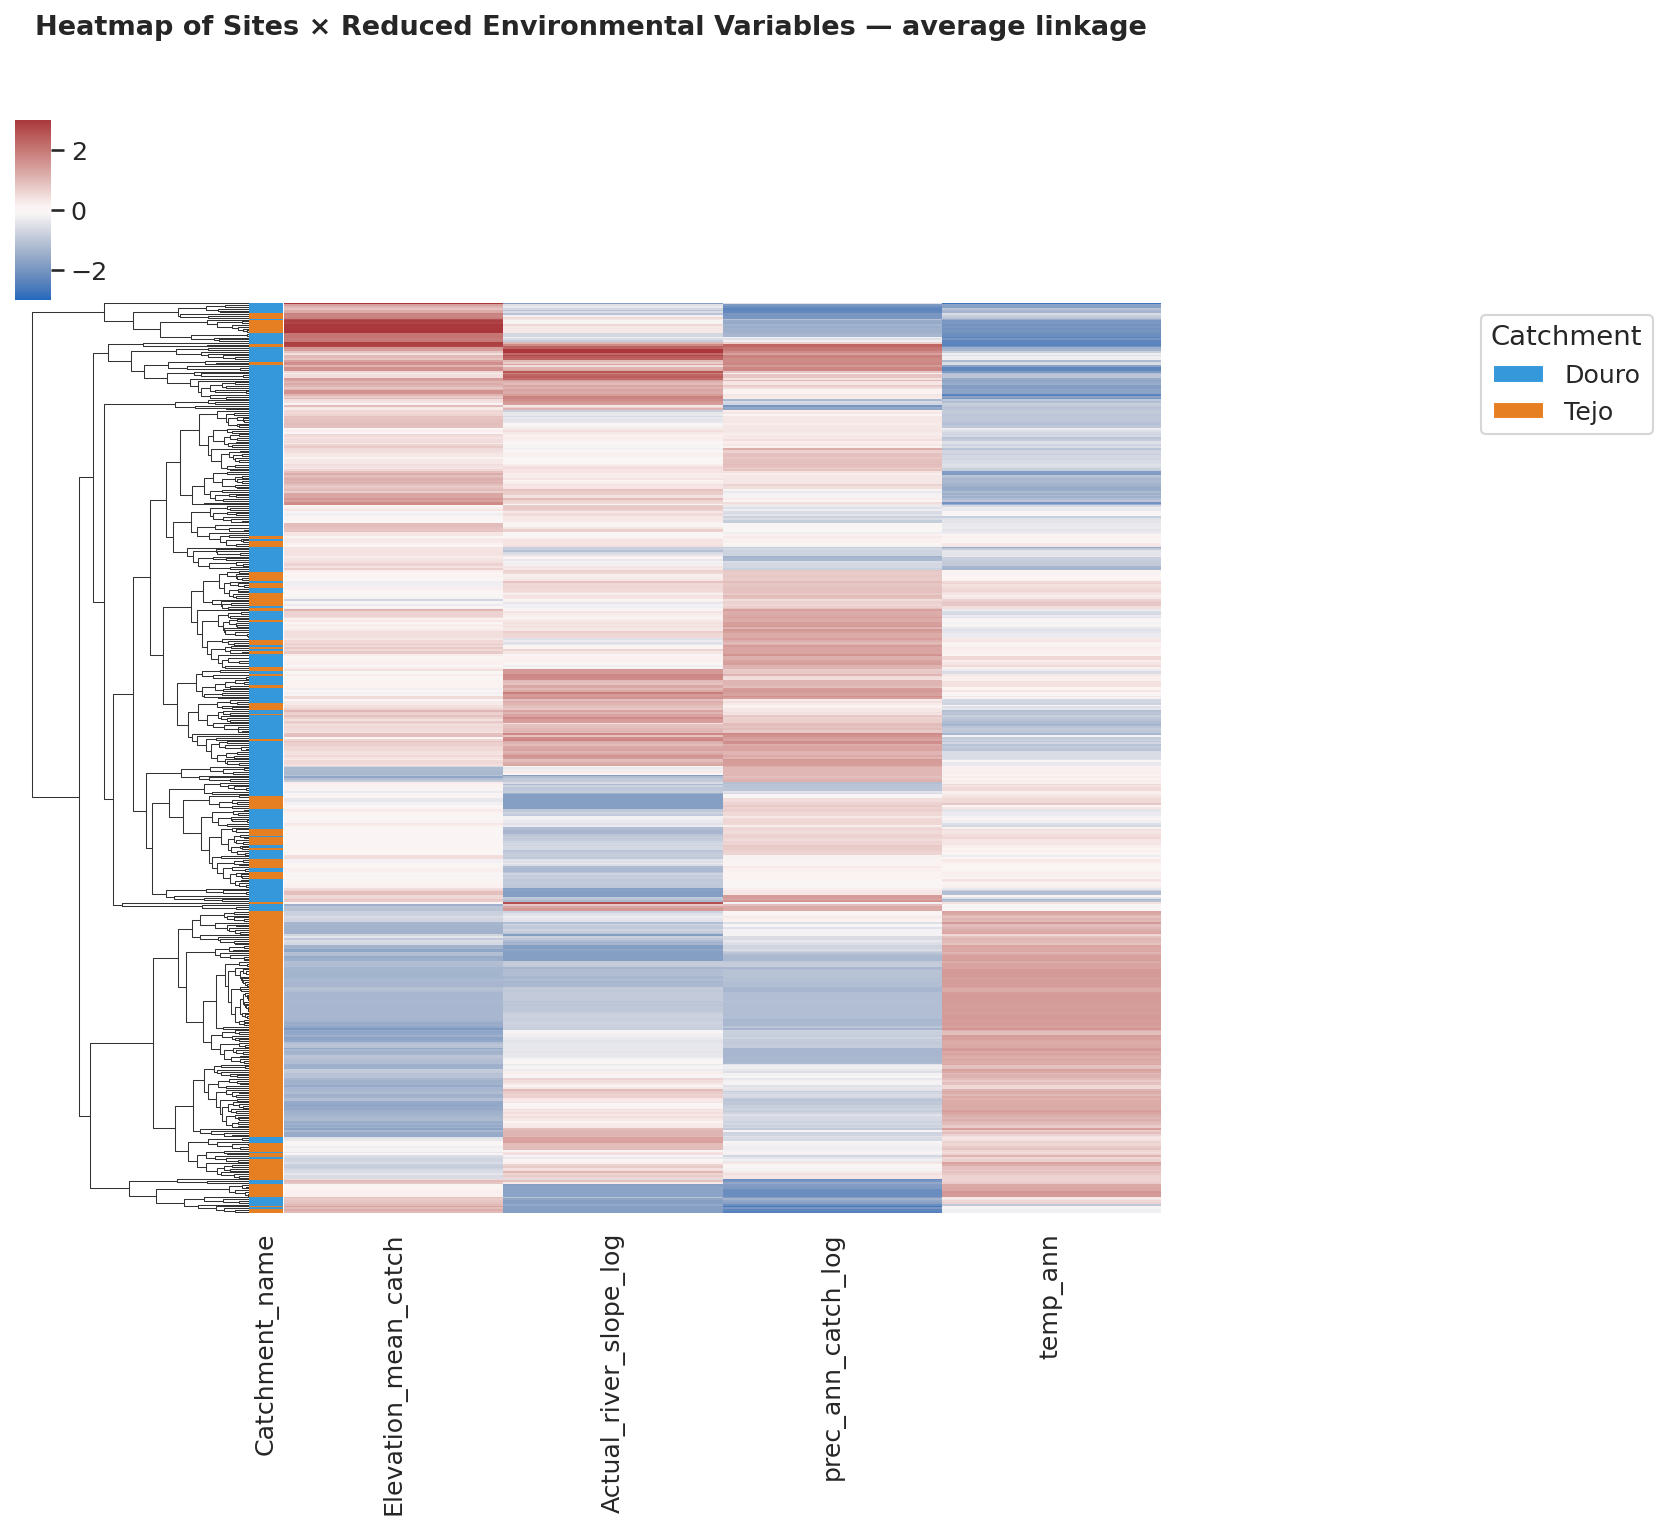

In [15]:
# @title Clustermap With the Reduced Variable Set

g = sns.clustermap(
    Xs_red,
    method='average', metric='euclidean',
    row_cluster=True, col_cluster=False,
    cmap='vlag', center=0, vmin=-3, vmax=3,
    figsize=(8, 10),
    yticklabels=False,
    row_colors=row_colors,
    cbar_pos=(0.02, 0.83, 0.03, 0.12),
)
g.fig.suptitle("Heatmap of Sites × Reduced Environmental Variables — average linkage",
               fontsize=13, fontweight='bold', y=1.02)

# Manual legend for the row-color bar
g.ax_heatmap.legend(
    handles=[Patch(facecolor='#3498db', label='Douro'),
             Patch(facecolor='#e67e22', label='Tejo')],
    title='Catchment', bbox_to_anchor=(1.35, 1.0), loc='upper left',
)
plt.show()

### Q3 redone — Variable dendrogram with the reduced set

With only four predictors left, the variable dendrogram should now show large fusion distances between every pair, confirming that the remaining predictors are non-redundant.

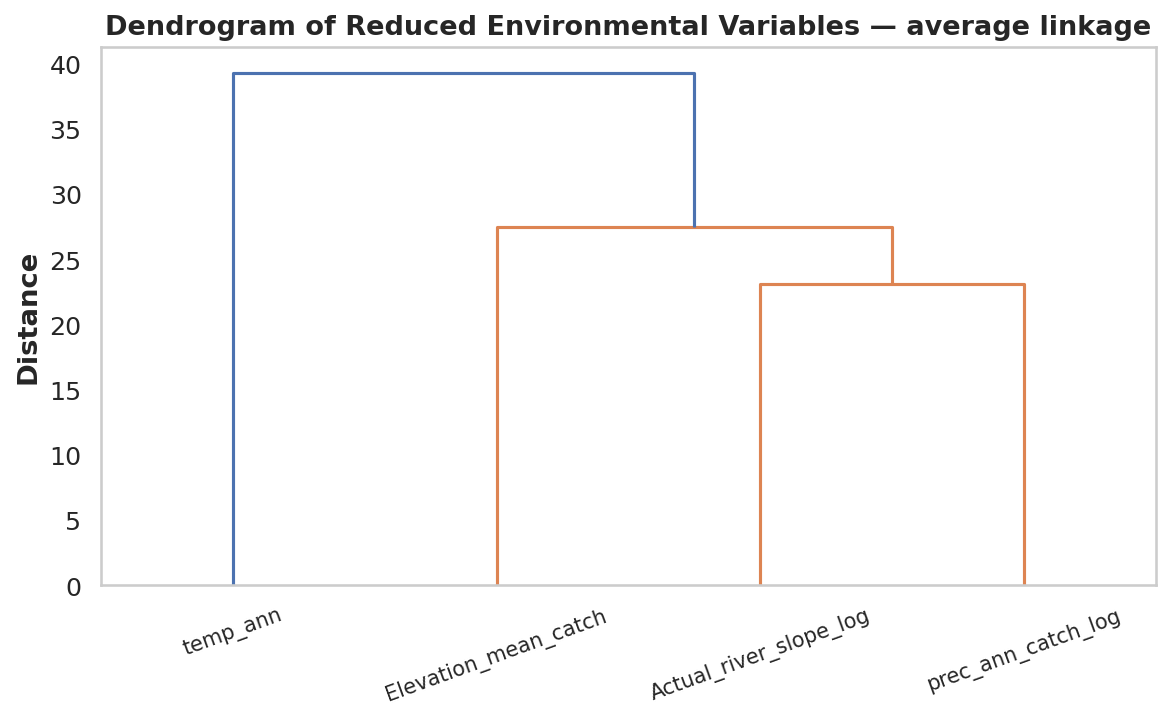

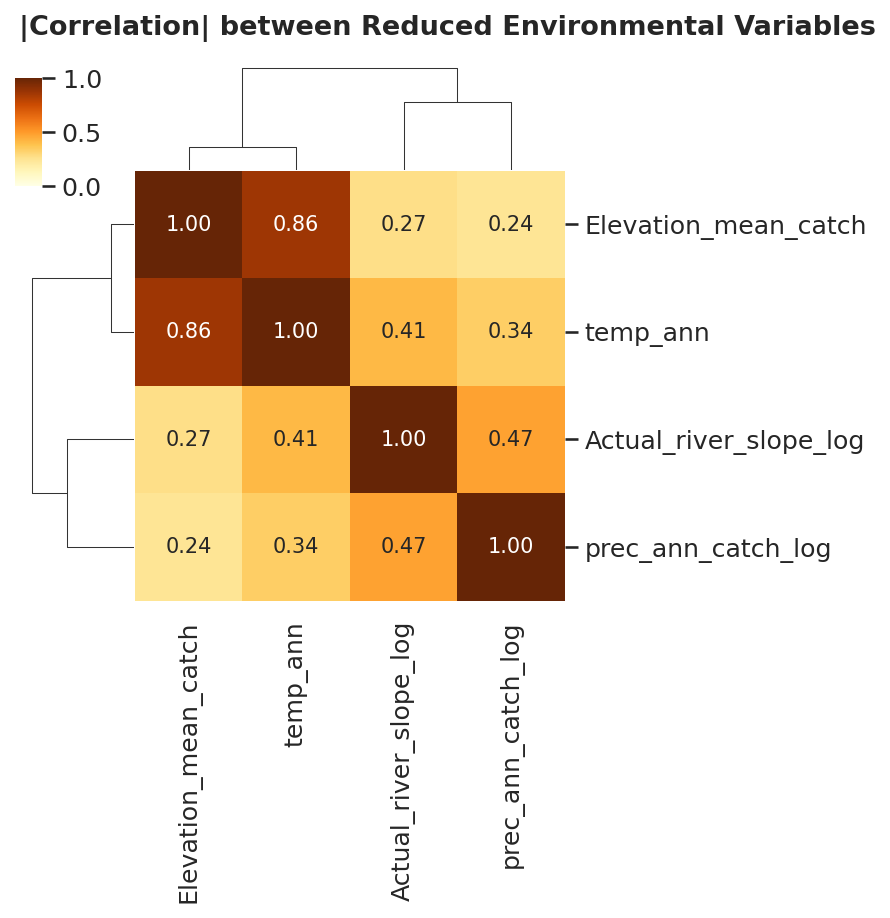

In [16]:
# @title Variable Dendrogram and Correlation Heatmap Using the Reduced Variable Set

# Dendrogram of variables
Z_vars_red = linkage(Xs_red.T.values, method='average', metric='euclidean')

fig, ax = plt.subplots(figsize=(8, 5))
dendrogram(Z_vars_red, labels=env_vars_red, leaf_rotation=20, leaf_font_size=10,
           color_threshold=0.7*max(Z_vars_red[:, 2]), ax=ax)
ax.set_title("Dendrogram of Reduced Environmental Variables — average linkage",
             fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Distance")
ax.grid(False)
plt.tight_layout()
plt.show()

# Correlation heatmap (clustered)
g = sns.clustermap(
    Xs_red.corr().abs(),
    method='average', metric='euclidean',
    cmap='YlOrBr', vmin=0, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    figsize=(6, 6),
    cbar_pos=(0.02, 0.83, 0.03, 0.12),
)
g.fig.suptitle("|Correlation| between Reduced Environmental Variables",
               fontsize=13, fontweight='bold', y=1.02)
plt.show()

#### Observation of Redoing Q1-Q3 after Dimension Reduction
- **Q1 (dendrograms, variable_n = 4):** After removing the extra similar variables, the four linkage trees are less controlled by the repeated temperature signal. The main pattern is still the same: warm climates are generally associated with low-altitude regions, whereas cold climates are typically found at higher altitudes. But now the clusters are cleaner because sites group together only when they truly share similar conditions, not because temperature was counted three times.
- **Q2 (clustermap, variable_n = 4):** The heatmap now has 4 columns instead of 7. Even so, the main story is unchanged. We see one group of warm, low sites, mostly Tejo, and one group of cold, high sites, mostly Douro. The plot looks less repetitive because the temperature pattern is not shown three times anymore.
- **Q3 (variable dendrogram, variable_n = 4):** The 4 variables we kept now join together only at larger distances in the dendrogram, and most cells in the correlation heatmap are light. This shows the variables are no longer strongly linked to each other. In other words, multicollinearity is gone and each variable brings its own information. This is exactly what a good regression model needs, as we saw in Exercise 7.

#### **Sources**

- GeeksforGeeks. (n.d.). Create a correlation matrix using Python. GeeksforGeeks. https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/
- Numiqo. (n.d.). Hierarchical cluster analysis. Numiqo. https://numiqo.com/tutorial/hierarchical-cluster-analysis
- Waskom, M. L. (2021). Seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021
- Waskom, M. (n.d.). seaborn.clustermap. Seaborn. https://seaborn.pydata.org/generated/seaborn.clustermap.html
- Raschka, S., Liu, Y. H., & Mirjalili, V. (2022). Working with unlabeled data — Clustering analysis. In Machine learning with PyTorch and Scikit-Learn (pp. 305–327). Packt Publishing.
